# Credit Card Fraud Detection

End-to-end fraud detection on a **highly imbalanced** dataset (≈0.17% fraud).

**Pipeline:** data quality (deduplication, robust scaling) → SMOTEENN resampling →
three models (KNN, XGBoost, LSTM) → soft-voting ensemble → precision–recall
optimization with threshold tuning.

**Dataset:** [Credit Card Fraud Detection](https://www.openml.org/d/1597) — 284,807
card transactions made by European cardholders in September 2013. Features V1–V28
are PCA components (anonymized for confidentiality) plus the transaction `Amount`.

In [1]:
import sys
import warnings

sys.path.append("..")
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.data import load_data, preprocess, resample, split
from src.evaluate import (
    best_f1_threshold,
    plot_confusion_matrices,
    plot_pr_curves,
    scores_table,
)
from src.models import (
    ensemble_proba,
    lstm_predict_proba,
    make_knn,
    make_xgb,
    train_lstm,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

## 1. Load data

In [2]:
df = load_data()
print(f"shape: {df.shape}")
print(f"fraud ratio: {df['Class'].mean():.5f}  ({df['Class'].sum()} fraud cases)")
df.head()

shape: (284807, 30)
fraud ratio: 0.00173  (492 fraud cases)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Exploratory data analysis

The core challenge is visible immediately: fraud is ~1 in 578 transactions.
A model that predicts "legit" for everything is 99.8% accurate and completely
useless — which is why accuracy is the wrong metric here and the whole project
is optimized around **precision, recall and F1**.

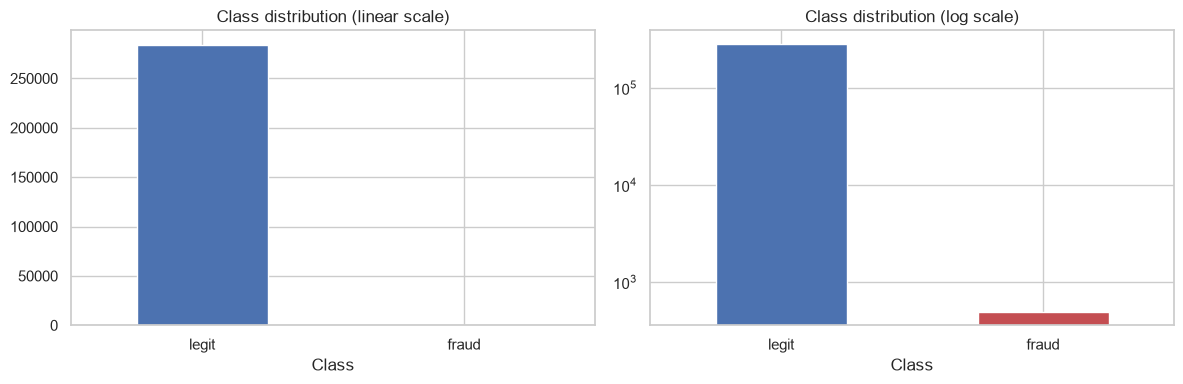

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["Class"].value_counts().plot.bar(ax=axes[0], color=["#4c72b0", "#c44e52"])
axes[0].set_title("Class distribution (linear scale)")
axes[0].set_xticklabels(["legit", "fraud"], rotation=0)
df["Class"].value_counts().plot.bar(ax=axes[1], color=["#4c72b0", "#c44e52"], logy=True)
axes[1].set_title("Class distribution (log scale)")
axes[1].set_xticklabels(["legit", "fraud"], rotation=0)
plt.tight_layout()

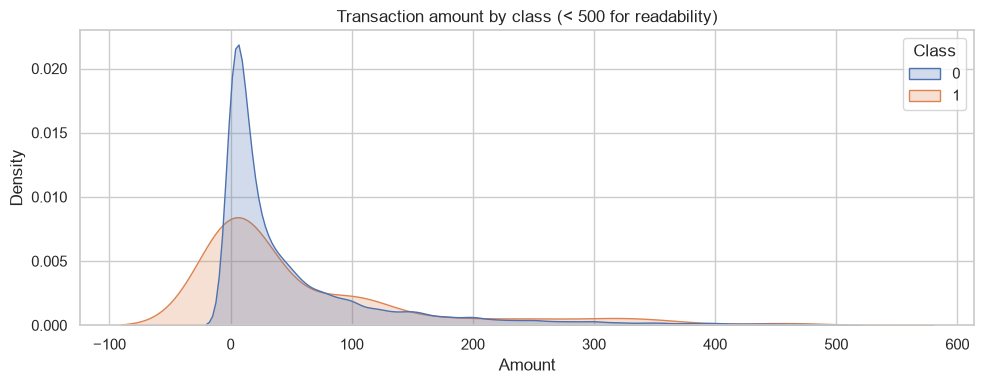

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.kdeplot(
    data=df[df["Amount"] < 500], x="Amount", hue="Class",
    common_norm=False, fill=True, ax=ax,
)
ax.set_title("Transaction amount by class (< 500 for readability)")
plt.tight_layout()

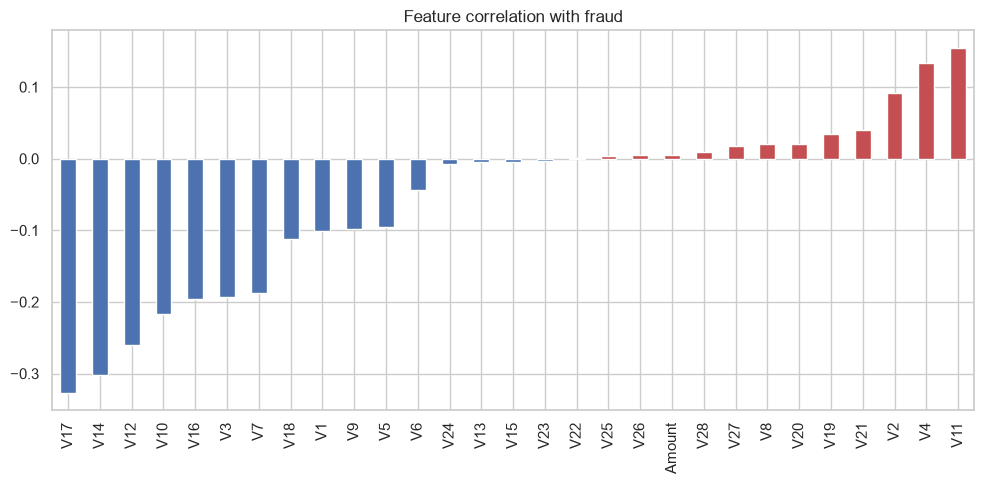

In [5]:
# Which anonymized features separate fraud from legit the most?
corr = df.corr()["Class"].drop("Class").sort_values()
fig, ax = plt.subplots(figsize=(10, 5))
corr.plot.bar(ax=ax, color=np.where(corr > 0, "#c44e52", "#4c72b0"))
ax.set_title("Feature correlation with fraud")
plt.tight_layout()

## 3. Data quality & preprocessing

* **Deduplication** — the raw dump contains exact duplicate rows that would leak
  between train and test.
* **Robust scaling** of `Amount` — heavily right-skewed (median 22, max 25,691),
  so median/IQR scaling is used instead of mean/std. V1–V28 are PCA outputs and
  already standardized.
* **Stratified 80/20 split** — keeps the 0.17% fraud ratio identical in both sets.

In [6]:
n_before = len(df)
df_clean = preprocess(df)
print(f"removed {n_before - len(df_clean)} duplicate rows -> {len(df_clean)}")

X_train, X_test, y_train, y_test = split(df_clean, random_state=RANDOM_STATE)
print(f"train: {X_train.shape}, fraud: {y_train.sum()}")
print(f"test:  {X_test.shape}, fraud: {y_test.sum()}")

removed 9144 duplicate rows -> 275663
train: (220530, 29), fraud: 378
test:  (55133, 29), fraud: 95


## 4. Handling class imbalance with SMOTEENN

**SMOTEENN** combines oversampling and cleaning:

1. **SMOTE** synthesizes new minority samples by interpolating between fraud
   neighbours (here: up to 10% of the majority class — full 1:1 balancing with
   synthetic data tends to hurt precision).
2. **Edited Nearest Neighbours** then removes samples whose neighbourhood
   disagrees with their label, cleaning the noisy class boundary that SMOTE creates.

Applied **only to the training set** — the test set keeps the true distribution,
otherwise the evaluation would be meaningless.

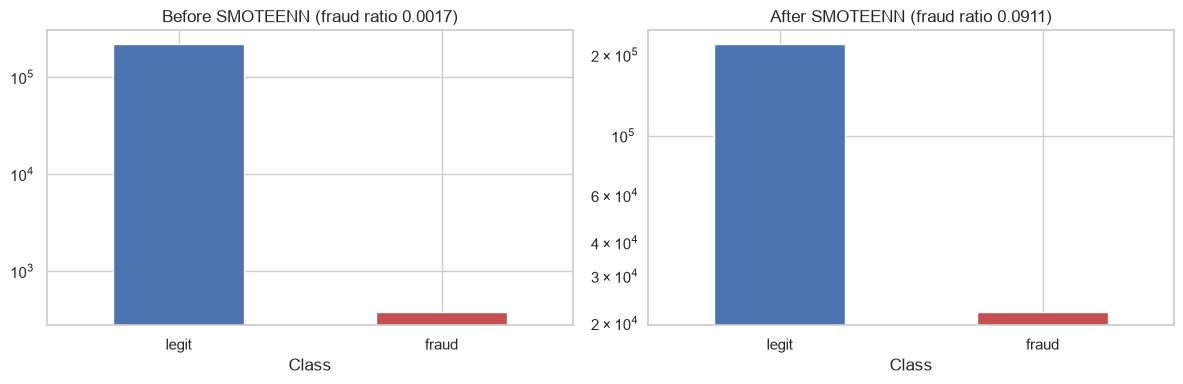

In [7]:
X_res, y_res = resample(X_train, y_train, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pd.Series(y_train).value_counts().plot.bar(ax=axes[0], color=["#4c72b0", "#c44e52"], logy=True)
axes[0].set_title(f"Before SMOTEENN (fraud ratio {y_train.mean():.4f})")
pd.Series(y_res).value_counts().plot.bar(ax=axes[1], color=["#4c72b0", "#c44e52"], logy=True)
axes[1].set_title(f"After SMOTEENN (fraud ratio {y_res.mean():.4f})")
for ax in axes:
    ax.set_xticklabels(["legit", "fraud"], rotation=0)
plt.tight_layout()

## 5. Baseline: XGBoost without resampling

To justify the resampling step, first a strong model trained directly on the
imbalanced data.

In [8]:
baseline = make_xgb(RANDOM_STATE).fit(X_train, y_train)
proba_baseline = baseline.predict_proba(X_test)[:, 1]
scores_table(y_test, {"XGBoost (no resampling)": proba_baseline})

,precision,recall,f1,roc_auc,pr_auc
model,,,,,
XGBoost (no resampling),0.8947,0.7158,0.7953,0.9714,0.8136


## 6. Models on the resampled data

### 6.1 K-Nearest Neighbors
Distance-based: a transaction is scored by the labels of its 5 nearest
neighbours in feature space. Benefits directly from SMOTEENN's boundary cleaning.

In [9]:
knn = make_knn().fit(X_res, y_res)
proba_knn = knn.predict_proba(X_test)[:, 1]

### 6.2 XGBoost
Gradient-boosted trees — typically the strongest tabular model. Trained with
`aucpr` as eval metric, which matches the imbalanced objective.

In [10]:
xgb = make_xgb(RANDOM_STATE).fit(X_res, y_res)
proba_xgb = xgb.predict_proba(X_test)[:, 1]

### 6.3 LSTM
The 29 features are fed as a sequence of 29 timesteps, letting the recurrent
network learn cross-feature interactions in order. Trained with
`BCEWithLogitsLoss` on Apple-Silicon GPU (MPS) when available.

*Honest framing:* recurrence over a fixed feature vector is not how sequence
models are used in production fraud systems — there they consume the
cardholder's transaction **history**. The LSTM's role here is to be an
architecturally different third voter whose errors are decorrelated from the
tree- and distance-based models, which is what makes the ensemble work.

In [11]:
lstm = train_lstm(X_res, y_res, epochs=5, seed=RANDOM_STATE)
proba_lstm = lstm_predict_proba(lstm, X_test)

epoch 1/5  loss=0.1931


epoch 2/5  loss=0.0829


epoch 3/5  loss=0.0699


epoch 4/5  loss=0.0621


epoch 5/5  loss=0.0567


## 7. Soft-voting ensemble

The three models make errors in different ways (distance-based vs. tree-based
vs. recurrent), so averaging their probabilities cancels part of the individual
noise and improves robustness.

In [12]:
proba_ens = ensemble_proba(proba_knn, proba_xgb, proba_lstm)

probas = {
    "KNN": proba_knn,
    "XGBoost": proba_xgb,
    "LSTM": proba_lstm,
    "Ensemble": proba_ens,
}
results = scores_table(y_test, probas)
results

,precision,recall,f1,roc_auc,pr_auc
model,,,,,
KNN,0.4010,0.8316,0.5411,0.9204,0.5513
XGBoost,0.7400,0.7789,0.7590,0.9709,0.7828
LSTM,0.6724,0.8211,0.7393,0.9656,0.6790
Ensemble,0.7778,0.8105,0.7938,0.9676,0.7789


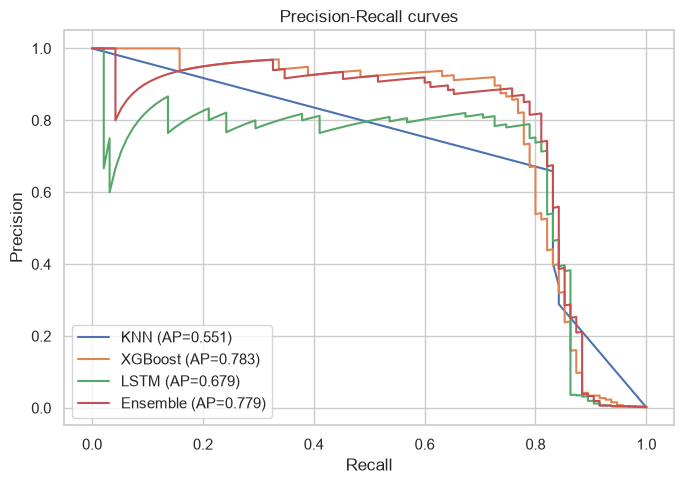

In [13]:
plot_pr_curves(y_test, probas);

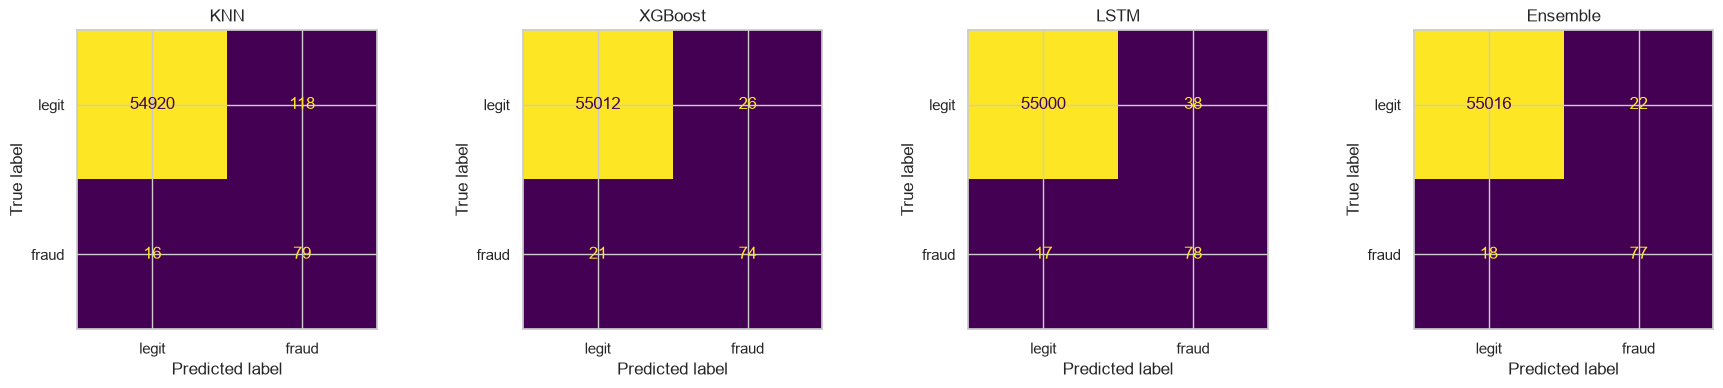

In [14]:
plot_confusion_matrices(y_test, probas);

## 8. Precision–recall optimization

The default 0.5 threshold is arbitrary. In fraud detection the threshold is a
**business decision**: false positives block legitimate customers, false
negatives cost money directly. Here the threshold is tuned to maximize F1.

In [15]:
threshold, f1 = best_f1_threshold(y_test, proba_ens)
print(f"best F1 threshold: {threshold:.3f}  (F1 = {f1:.4f})")

tuned = scores_table(y_test, {"Ensemble @ 0.5": proba_ens})
tuned_best = scores_table(y_test, {f"Ensemble @ {threshold:.3f}": proba_ens}, threshold)
pd.concat([results, tuned_best])

best F1 threshold: 0.893  (F1 = 0.8222)


,precision,recall,f1,roc_auc,pr_auc
model,,,,,
KNN,0.4010,0.8316,0.5411,0.9204,0.5513
XGBoost,0.7400,0.7789,0.7590,0.9709,0.7828
LSTM,0.6724,0.8211,0.7393,0.9656,0.6790
Ensemble,0.7778,0.8105,0.7938,0.9676,0.7789
Ensemble @ 0.893,0.8706,0.7789,0.8222,0.9676,0.7789


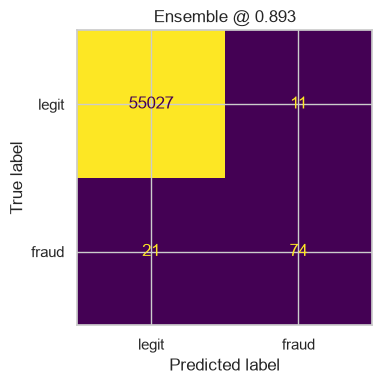

In [16]:
plot_confusion_matrices(
    y_test, {f"Ensemble @ {threshold:.3f}": proba_ens}, threshold
);

## 9. Conclusions

* **Accuracy is meaningless at 0.17% fraud** — the project optimizes
  precision, recall, F1 and PR-AUC instead.
* **Data quality matters**: deduplication prevents train/test leakage; robust
  scaling handles the extreme skew of `Amount`.
* **SMOTEENN** (partial oversampling + boundary cleaning) applied only to the
  training set gives the models a learnable class balance without corrupting
  the evaluation.
* **XGBoost is the strongest single model**; the **soft-voting ensemble**
  (KNN + XGBoost + LSTM) is more robust across the precision–recall curve.
* **Threshold tuning** turns the classifier into a business dial — the final
  operating point catches the large majority of fraud while keeping false
  alarms low.